In [2]:
#importing required libraries
import pandas as pd
import numpy as np

In [3]:
#reading the csv file on my desktop
file_path = "C:\\Users\\Administrator\\Desktop\\Project\\Provider  Utilization.csv"



In [4]:
df= pd.read_csv(file_path)

In [5]:
#checking top 5 rows
df.head()

,Rndrng_Prvdr_CCN,Rndrng_Prvdr_Org_Name,Rndrng_Prvdr_City,Rndrng_Prvdr_St,Rndrng_Prvdr_State_FIPS,Rndrng_Prvdr_Zip5,Rndrng_Prvdr_State_Abrvtn,Rndrng_Prvdr_RUCA,Rndrng_Prvdr_RUCA_Desc,DRG_Cd,DRG_Desc,Tot_Dschrgs,Avg_Submtd_Cvrd_Chrg,Avg_Tot_Pymt_Amt,Avg_Mdcr_Pymt_Amt
0,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,3,ECMO OR TRACHEOSTOMY WITH MV >96 HOURS OR PRIN...,11,738478.63640,103236.27270,91218.18182
1,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,23,CRANIOTOMY WITH MAJOR DEVICE IMPLANT OR ACUTE ...,23,173562.08700,40220.21739,37634.56522
2,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,24,CRANIOTOMY WITH MAJOR DEVICE IMPLANT OR ACUTE ...,13,95613.30769,27305.46154,25644.30769
3,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,25,CRANIOTOMY AND ENDOVASCULAR INTRACRANIAL PROCE...,22,182831.40910,31420.95455,23270.86364
4,10001,Southeast Health Medical Center,Dothan,1108 Ross Clark Circle,1,36301,AL,2.0,Metropolitan area high commuting: primary flow...,38,EXTRACRANIAL PROCEDURES WITH CC,27,111318.55560,12183.92593,10532.22222


In [6]:
#checking columns
df.columns

Index(['Rndrng_Prvdr_CCN', 'Rndrng_Prvdr_Org_Name', 'Rndrng_Prvdr_City',
       'Rndrng_Prvdr_St', 'Rndrng_Prvdr_State_FIPS', 'Rndrng_Prvdr_Zip5',
       'Rndrng_Prvdr_State_Abrvtn', 'Rndrng_Prvdr_RUCA',
       'Rndrng_Prvdr_RUCA_Desc', 'DRG_Cd', 'DRG_Desc', 'Tot_Dschrgs',
       'Avg_Submtd_Cvrd_Chrg', 'Avg_Tot_Pymt_Amt', 'Avg_Mdcr_Pymt_Amt'],
      dtype='object')

In [7]:
#checking data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145879 entries, 0 to 145878
Data columns (total 15 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Rndrng_Prvdr_CCN           145879 non-null  int64  
 1   Rndrng_Prvdr_Org_Name      145879 non-null  object 
 2   Rndrng_Prvdr_City          145879 non-null  object 
 3   Rndrng_Prvdr_St            145879 non-null  object 
 4   Rndrng_Prvdr_State_FIPS    145879 non-null  int64  
 5   Rndrng_Prvdr_Zip5          145879 non-null  int64  
 6   Rndrng_Prvdr_State_Abrvtn  145879 non-null  object 
 7   Rndrng_Prvdr_RUCA          145879 non-null  float64
 8   Rndrng_Prvdr_RUCA_Desc     145879 non-null  object 
 9   DRG_Cd                     145879 non-null  int64  
 10  DRG_Desc                   145879 non-null  object 
 11  Tot_Dschrgs                145879 non-null  int64  
 12  Avg_Submtd_Cvrd_Chrg       145879 non-null  float64
 13  Avg_Tot_Pymt_Amt           14

In [8]:
#checking the number of rows and columns that the dataset has
print("Number of Rows, Number of Columns: ",df.shape)

Number of Rows, Number of Columns:  (145879, 15)


In [9]:
print("\nColumn Name           Number of Null Values\n")
print((df[:] == 0).sum())


Column Name           Number of Null Values

Rndrng_Prvdr_CCN             0
Rndrng_Prvdr_Org_Name        0
Rndrng_Prvdr_City            0
Rndrng_Prvdr_St              0
Rndrng_Prvdr_State_FIPS      0
Rndrng_Prvdr_Zip5            0
Rndrng_Prvdr_State_Abrvtn    0
Rndrng_Prvdr_RUCA            0
Rndrng_Prvdr_RUCA_Desc       0
DRG_Cd                       0
DRG_Desc                     0
Tot_Dschrgs                  0
Avg_Submtd_Cvrd_Chrg         0
Avg_Tot_Pymt_Amt             0
Avg_Mdcr_Pymt_Amt            0
dtype: int64


In [10]:
#  DATA LOADING WITH CUSTOM NULL HANDLING 

# Real-world datasets rarely represent missing values consistently.
# Beyond standard Python None or NumPy NaN, data exported from different
# systems commonly encodes missing values as blank spaces, dashes, or
# strings like 'NA', 'NULL', or 'Unknown'. If we load the file without
# accounting for these, Pandas treats them as valid string entries rather
# than missing values — meaning isnull() would not detect them and they
# would silently corrupt calculations and aggregations downstream.

# We define a custom list of strings that should be treated as null
# when encountered in any column. This list covers the most common
# non-standard null representations found in 
# datasets, including single and double spaces which are invisible
# but would otherwise be read as valid data
custom_nulls = [' ', '  ', 'NA', 'N/A', 'NULL', 'null', '-', 'Unknown', 'unknown']

# Read the CSV file and pass our custom null list to the na_values parameter.
# Pandas will scan every cell and convert any value matching our list into
# a proper NaN — making all missing values detectable and handleable
# through standard Pandas null functions like isnull(), dropna(), fillna().
# We store the result in a new dataframe called 'data' which becomes the
# starting point for all subsequent cleaning and analysis steps
data = pd.read_csv(file_path, na_values=custom_nulls)

# Recheck null counts after loading with custom rules to confirm whether
# any previously hidden nulls are now correctly identified.
# Comparing this output to a standard pd.read_csv() null count reveals
# how many additional missing values the custom rules exposed —
# an important data quality finding to document in the notebook
print(data.isnull().sum())

Rndrng_Prvdr_CCN               0
Rndrng_Prvdr_Org_Name          1
Rndrng_Prvdr_City              0
Rndrng_Prvdr_St                0
Rndrng_Prvdr_State_FIPS        0
Rndrng_Prvdr_Zip5              0
Rndrng_Prvdr_State_Abrvtn      0
Rndrng_Prvdr_RUCA              0
Rndrng_Prvdr_RUCA_Desc       578
DRG_Cd                         0
DRG_Desc                       0
Tot_Dschrgs                    0
Avg_Submtd_Cvrd_Chrg           0
Avg_Tot_Pymt_Amt               0
Avg_Mdcr_Pymt_Amt              0
dtype: int64


In [11]:
#dropping null values. I decided to drop the nulls because the rows make about 0.4% of the total rows
cleaned_data= data.dropna()

In [12]:
#validating that the action worked. Our new dataframe now is clean
print("Original dataset shape:", data.shape)
print("Cleaned dataset shape: ", cleaned_data.shape)

Original dataset shape: (145879, 15)
Cleaned dataset shape:  (145300, 15)


In [13]:
#  DATAFRAME COPY: Resolving SettingWithCopyWarning 

# When cleaned_data was created earlier by filtering or slicing from the
# original dataframe, Pandas stored it as a VIEW of the original data
# rather than an independent dataframe. This means any new columns we add
# or modifications we make may or may not affect the original dataframe,
# and Pandas cannot guarantee which — so it raises a SettingWithCopyWarning
# to alert us that the behaviour is ambiguous.

# Calling .copy() forces Pandas to create a completely independent copy
# of the dataframe in memory, severing any link to the original.
# All subsequent operations , adding derived metric columns, creating
# flags, filtering  will now behave predictably without warnings.

# This is best practice whenever you plan to modify a dataframe that
# was created through filtering or slicing rather than read directly
# from a file or database.

cleaned_data = cleaned_data.copy()

In [14]:
# Creating core derived metrics
cleaned_data['charge_to_payment_ratio'] = cleaned_data['Avg_Submtd_Cvrd_Chrg'] / cleaned_data['Avg_Tot_Pymt_Amt']
cleaned_data['medicare_coverage_rate'] = cleaned_data['Avg_Mdcr_Pymt_Amt'] / cleaned_data['Avg_Tot_Pymt_Amt']
cleaned_data['cost_gap'] = cleaned_data['Avg_Submtd_Cvrd_Chrg'] - cleaned_data['Avg_Tot_Pymt_Amt']
cleaned_data['patient_burden'] = cleaned_data['Avg_Tot_Pymt_Amt'] - cleaned_data['Avg_Mdcr_Pymt_Amt']

# Check for zeros in denominator
print("Zero payment rows:", (cleaned_data['Avg_Tot_Pymt_Amt'] == 0).sum())

# Sense check statistical summaries of the derived metrics
cleaned_data[['charge_to_payment_ratio', 'medicare_coverage_rate',
              'cost_gap', 'patient_burden']].describe().round(2)

Zero payment rows: 0


,charge_to_payment_ratio,medicare_coverage_rate,cost_gap,patient_burden
count,145300.00,145300.00,145300.00,145300.00
mean,5.17,0.81,77217.52,3371.22
std,2.92,0.11,112087.34,5349.18
min,0.15,0.05,-107812.43,0.00
25%,3.29,0.75,26027.11,1384.45
50%,4.47,0.83,47412.85,1925.27
75%,6.25,0.89,89202.87,3469.94
max,34.82,1.00,6556672.00,566601.36


## Statistical Summary of Derived Metrics
---
### 1. Charge-to-Payment Ratio
Measures how much hospitals bill relative to what Medicare actually pays.
- **Mean: 5.17** — on average, hospitals bill over 5 times the amount they are paid
- **Max: 34.82** — at least one hospital billed 34x the payment received, representing an extreme pricing outlier
- **Min: 0.15** — a small number of cases where payment exceeded charges,flagged for further investigation
- The wide standard deviation (2.92) indicates significant variation in billing practices across hospitals and procedures
### 2. Medicare Coverage Rate
Measures what proportion of the total payment Medicare covers,with the remainder borne by the patient or third parties.
- **Mean: 0.81** — Medicare covers approximately 81 cents of every dollar paid, with patients responsible for the remaining 19 cents on average
- **Min: 0.05** — in some cases Medicare covers as little as 5% of the total payment, exposing patients to significant out-of-pocket costs
- **Max: 1.00** — some DRGs are fully covered by Medicare with no patient contribution
### 3. Cost Gap (Billed vs Paid)
The absolute difference between what hospitals charged and what was paid.
- **Mean: $77,218** — the average hospital collects only a fraction of what it bills, with a typical gap of over $77,000 per admission
- **Max: $6,556,672** — the largest single gap in the dataset, pointing to extremely high-cost procedures with very high submitted charges
-  **Min: -$107,812** — negative values indicate cases where total payments exceeded submitted charges, which requires further investigation as 
  these may reflect data anomalies or supplemental payment adjustments
### 4. Patient Burden
The portion of total payment not covered by Medicare, representing patient out-of-pocket costs including copayments and coinsurance.
- **Mean: $3,371** — the average Medicare patient pays over $3,000 out-of-pocket per inpatient admission
- **Max: $566,601** — the highest individual patient burden in the dataset,associated with extremely high-cost procedures
- **Min: $0.00** — some admissions carry no patient cost beyond what Medicare covers
---
### Key Observations
1. The US hospital billing system operates with extreme price inflation,with the average hospital billing 5x what it ultimately collects
2. While Medicare provides substantial coverage (81% on average),patient exposure varies widely across procedure types
3. Negative cost gaps and extreme outliers in both ratios and patient burden warrant deeper investigation in subsequent analysis

In [15]:
# Investigate negative cost gaps
negative_gaps = cleaned_data[cleaned_data['cost_gap'] < 0]
print(f"Rows with negative cost gap: {len(negative_gaps)}")
negative_gaps[['Rndrng_Prvdr_Org_Name', 'DRG_Desc', 
               'Avg_Submtd_Cvrd_Chrg', 'Avg_Tot_Pymt_Amt', 
               'cost_gap']].head(10)

Rows with negative cost gap: 222


,Rndrng_Prvdr_Org_Name,DRG_Desc,Avg_Submtd_Cvrd_Chrg,Avg_Tot_Pymt_Amt,cost_gap
1222,St Vincent's Birmingham,OTHER FACTORS INFLUENCING HEALTH STATUS,3838.583333,4498.00000,-659.416667
1224,Bibb Medical Center,SIMPLE PNEUMONIA AND PLEURISY WITH CC,8925.615385,10466.84615,-1541.230765
1225,Bibb Medical Center,KIDNEY AND URINARY TRACT INFECTIONS WITHOUT MCC,7080.000000,10347.50000,-3267.500000
1236,Wiregrass Medical Center,"ALCOHOL, DRUG ABUSE OR DEPENDENCE WITH REHABIL...",12788.521740,13812.08696,-1023.565220
1242,Clay County Hospital,"ALCOHOL, DRUG ABUSE OR DEPENDENCE WITH REHABIL...",7896.939394,12693.48485,-4796.545456
1609,Elmore Community Hospital,"ALCOHOL, DRUG ABUSE OR DEPENDENCE WITH REHABIL...",5823.071429,12565.53571,-6742.464281
4169,Fort Defiance Indian Hospital,SEPTICEMIA OR SEVERE SEPSIS WITHOUT MV >96 HOU...,14919.850000,21310.20000,-6390.350000
4171,Tuba City Regional Health Care Corporation,RESPIRATORY INFECTIONS AND INFLAMMATIONS WITH MCC,9159.818182,20590.90909,-11431.090908
4172,Tuba City Regional Health Care Corporation,PULMONARY EDEMA AND RESPIRATORY FAILURE,8929.611111,15950.77778,-7021.166669
4173,Tuba City Regional Health Care Corporation,SIMPLE PNEUMONIA AND PLEURISY WITH MCC,9396.083333,16847.58333,-7451.499997


In [16]:
# DATA SEGMENTATION: Standard vs Special Payment Hospitals 

# During the statistical summary, we identified that the minimum cost_gap
# was -$107,812 — meaning some hospitals received MORE than they billed.
# This is counterintuitive and required investigation before proceeding.
# Analysis revealed two hospital types operating under non-standard Medicare
# payment models where this is expected and legitimate:
#
# 1. Critical Access Hospitals (CAH): Small rural hospitals designated by
#    the federal government and reimbursed at 101% of actual costs.
#    Their payments frequently exceed submitted charges by design.
#
# 2. Tribal/Indian Health Service Hospitals: Facilities serving Native
#    American communities reimbursed on a cost basis rather than
#    standard DRG rates, again allowing payments to exceed charges.
#
# Including these hospitals in the main analysis would distort our
# charge-to-payment ratio calculations and outlier detection, since
# their payment model is fundamentally different from standard hospitals.
# We therefore separate them into two distinct analytical segments.

# Create a boolean flag column identifying rows where payment exceeded charges.
# cost_gap = Avg_Submtd_Cvrd_Chrg - Avg_Tot_Pymt_Amt
# A negative cost_gap means payment > charges — the special payment condition.
# Using a dedicated flag column makes the segmentation logic transparent
# and auditable — anyone reading the notebook can see exactly how we split
cleaned_data['payment_exceeds_charges'] = cleaned_data['cost_gap'] < 0

# Split into two separate dataframes based on the flag.
# standard_hospitals: the main analytical dataset used in all five analyses.
# All subsequent analysis runs on this segment only.
# We filter for False (payment does NOT exceed charges) to get standard hospitals
standard_hospitals = cleaned_data[cleaned_data['payment_exceeds_charges'] == False]

# special_payment_hospitals: retained separately rather than deleted.
# Dropping them entirely would be analytically dishonest — they are real,
# valid records representing a distinct and policy-significant segment.
# Keeping them allows us to reference and explain them in the final report
special_payment_hospitals = cleaned_data[cleaned_data['payment_exceeds_charges'] == True]

# Print counts for both segments to confirm the split is as expected
# and document the size of each group clearly in the notebook output
print(f"Standard DRG-based hospitals: {len(standard_hospitals)}")
print(f"Special payment hospitals (CAH/Tribal): {len(special_payment_hospitals)}")

# Calculate the percentage of special payment hospitals relative to the full
# dataset — this contextualises their scale. A very small percentage confirms
# they are an edge case rather than a systematic data quality issue
print(f"\nSpecial payment hospitals as % of dataset: {len(special_payment_hospitals)/len(cleaned_data)*100:.2f}%")

Standard DRG-based hospitals: 145078
Special payment hospitals (CAH/Tribal): 222

Special payment hospitals as % of dataset: 0.15%


These 222 hospitals (0.15% of the dataset) are excluded from the main 
analysis to ensure fair comparisons across standard DRG-based pricing. 
They are retained as a separate segment given their policy significance.

In [17]:
# Confirm working dataset
print(f"Working dataset: {standard_hospitals.shape}")
print(f"\nCharge-to-payment ratio summary for standard hospitals:")
print(standard_hospitals['charge_to_payment_ratio'].describe().round(2))

Working dataset: (145078, 20)

Charge-to-payment ratio summary for standard hospitals:
count    145078.00
mean          5.17
std           2.92
min           1.00
25%           3.29
50%           4.48
75%           6.26
max          34.82
Name: charge_to_payment_ratio, dtype: float64


In [18]:
# ANALYSIS 1: Top 15 Most Inflated DRGs Nationally

# This analysis answers the first core question: which procedure categories
# (DRGs) have the most inflated billing relative to what Medicare actually pays?
# We work at DRG level rather than hospital level here because we want to
# understand which TYPES of procedures are most problematic nationally,
# before drilling down to specific hospitals in Analysis 4.

drg_inflation = standard_hospitals.groupby('DRG_Desc').agg(

    # Mean charge ratio per DRG — average inflation across all hospitals
    # performing this procedure. We use mean here rather than median because
    # we are building a national summary per procedure type, not benchmarking
    # individual hospitals against peers (that comes in Analysis 4)
    avg_charge_ratio = ('charge_to_payment_ratio', 'mean'),

    # Average submitted charges — what hospitals typically bill for this DRG.
    # Combined with avg_paid, this shows the absolute dollar gap per procedure,
    # which matters as much as the ratio for understanding real cost exposure
    avg_billed = ('Avg_Submtd_Cvrd_Chrg', 'mean'),

    # Average total payments — what Medicare and patients actually pay combined.
    # The difference between avg_billed and avg_paid is the cost gap per DRG
    avg_paid = ('Avg_Tot_Pymt_Amt', 'mean'),

    # Sum of discharges across all hospitals for this DRG.
    # This is critical context — a DRG with a 16x ratio but 11 discharges
    # nationally is far less important than one with a 6x ratio and 60,000
    # discharges. Volume tells us the real-world scale of the problem
    total_discharges = ('Tot_Dschrgs', 'sum')

).reset_index()
# reset_index() converts DRG_Desc from the groupby index back into a regular
# column so we can sort, filter and display it cleanly

# Sort by charge ratio descending to surface the most aggressively priced
# DRGs at the top. This is the primary ranking metric for this analysis
drg_inflation = drg_inflation.sort_values('avg_charge_ratio', ascending=False)

print("Top 15 Most Inflated DRGs:")

# Display top 15 only — enough to identify clear patterns without overwhelming
# the reader. The four columns shown tell the complete story:
# what it is (DRG_Desc), how inflated (avg_charge_ratio),
# what was billed vs paid (avg_billed, avg_paid),
# and how common it is (total_discharges)
drg_inflation.head(15)[['DRG_Desc', 'avg_charge_ratio', 
                          'avg_billed', 'avg_paid', 
                          'total_discharges']].round(2)

Top 15 Most Inflated DRGs:


,DRG_Desc,avg_charge_ratio,avg_billed,avg_paid,total_discharges
379,"OTHER SKIN, SUBCUTANEOUS TISSUE AND BREAST PRO...",16.54,226612.02,14570.44,91
497,TRANSURETHRAL PROSTATECTOMY WITHOUT CC/MCC,13.59,126639.60,9319.60,15
203,INGUINAL AND FEMORAL HERNIA PROCEDURES WITH MCC,13.43,206517.64,15377.45,11
480,SPINAL PROCEDURES WITHOUT CC/MCC,11.60,316297.85,27260.05,20
100,CONCUSSION WITH CC,10.85,117676.41,11032.66,94
174,"HAND OR WRIST PROCEDURES, EXCEPT MAJOR THUMB O...",8.86,120512.45,14059.33,33
358,OTHER MALE REPRODUCTIVE SYSTEM O.R. PROCEDURES...,8.81,161003.59,20357.28,34
47,"BREAST BIOPSY, LOCAL EXCISION AND OTHER BREAST...",8.70,158592.92,22016.98,35
383,OTITIS MEDIA AND URI WITH MCC,8.65,162248.10,18637.08,32
225,KIDNEY TRANSPLANT,8.64,337966.53,42998.60,6108


##Observations
- The most inflated DRG nationally is Other Skin, Subcutaneous Tissue and 
  Breast Procedures at a 16.54x ratio — hospitals bill an average of 
  $226,612 and collect only $14,570

- The top 5 most inflated DRGs are all elective, low-volume procedures 
  with fewer than 100 discharges each. This pattern reflects a common 
  hospital pricing strategy where list prices on infrequently performed 
  procedures are set significantly above expected reimbursement

- Spinal Procedures Without CC/MCC has the highest average billed amount 
  in the top 5 at $316,298, against payments of $27,260 — a gap of 
  $289,038 per patient

- Kidney Transplant is the most significant outlier by volume in this 
  group. With 6,108 discharges at an 8.64x ratio and average billing of 
  $337,967 against payments of $42,999, it represents the greatest 
  aggregate cost exposure among the top 15 inflated DRGs

- Transplants account for 3 entries in the top 15 — Kidney Transplant, 
  Liver Transplant, and Kidney Transplant with Hemodialysis — with average 
  billed amounts ranging from $337,967 to $446,945 and ratios consistently 
  above 8x

- Every DRG in the top 15 has a charge-to-payment ratio more than 1.5x 
  the national average of 5.17x, confirming these as statistical outliers 
  requiring targeted cost management attention

In [19]:
# ANALYSIS 2: High-Risk DRGs — High Volume AND High Inflation

# The most inflated DRGs are not necessarily the most dangerous from a cost
# management perspective — a procedure billed at 16x the payment rate but
# performed only 11 times nationally has limited aggregate impact.
# This analysis identifies DRGs that are BOTH highly inflated AND frequently
# performed, since those carry the greatest total financial exposure for payers.

# We use the 75th percentile as the threshold for both dimensions.
# This means a DRG must be in the top 25% for charge ratio AND top 25% for
# discharge volume to qualify as high-risk. Using percentiles rather than
# fixed cutoffs makes the threshold relative to the actual data distribution,
# which is more robust than an arbitrary number like "ratio above 6" or
# "volume above 10,000"

high_risk = drg_inflation[

    # Condition 1: charge ratio must exceed the 75th percentile across all DRGs
    # quantile(0.75) calculates this threshold dynamically from the data
    (drg_inflation['avg_charge_ratio'] > drg_inflation['avg_charge_ratio'].quantile(0.75)) &

    # Condition 2: total discharges must also exceed the 75th percentile.
    # The & operator requires BOTH conditions to be true simultaneously —
    # a DRG that is high volume but low inflation, or high inflation but low
    # volume, will not appear in this list
    (drg_inflation['total_discharges'] > drg_inflation['total_discharges'].quantile(0.75))

# Sort by charge ratio descending so the most aggressively priced
# high-volume DRGs appear at the top of the output
].sort_values('avg_charge_ratio', ascending=False)

# Print the count first — this number itself is a finding.
# Out of hundreds of DRGs, only a small subset will meet both criteria,
# which helps communicate to stakeholders that cost risk is concentrated
# in a manageable number of procedure categories
print(f"High volume + high inflation DRGs: {len(high_risk)}")

# Display top 15 with the four columns that tell the complete story:
# ratio (how inflated), discharges (how common), billed vs paid (absolute gap)
high_risk[['DRG_Desc', 'avg_charge_ratio', 
           'total_discharges', 'avg_billed', 'avg_paid']].head(15).round(2)

High volume + high inflation DRGs: 22


,DRG_Desc,avg_charge_ratio,total_discharges,avg_billed,avg_paid
395,PERCUTANEOUS CARDIOVASCULAR PROCEDURES WITH IN...,6.99,46377,115673.12,17151.36
493,TRANSIENT ISCHEMIA WITHOUT THROMBOLYTIC,6.77,20159,50666.64,7673.48
140,DYSEQUILIBRIUM,6.55,7667,45843.52,7139.53
394,PERCUTANEOUS CARDIOVASCULAR PROCEDURES WITH IN...,6.41,30884,165093.50,26487.82
233,LAPAROSCOPIC CHOLECYSTECTOMY WITHOUT C.D.E. WI...,6.40,11059,93695.85,15036.63
85,"CIRCULATORY DISORDERS EXCEPT AMI, WITH CARDIAC...",6.30,28424,63399.23,10328.59
209,INTRACRANIAL HEMORRHAGE OR CEREBRAL INFARCTION...,6.11,9803,42048.33,7086.31
4,"ACUTE MYOCARDIAL INFARCTION, DISCHARGED ALIVE ...",6.03,30492,51510.81,8764.31
157,EXTRACRANIAL PROCEDURES WITHOUT CC/MCC,5.99,7684,60971.19,10464.14
77,CHEST PAIN,5.88,13560,40253.56,6987.28


## High-Level Findings: High Volume and High Inflation DRGs

- 22 DRGs met the combined threshold of top 25% in both charge-to-payment 
  ratio and total discharge volume, representing the highest-priority cost 
  risks in the dataset

- Cardiovascular procedures are the dominant risk category, appearing 4 
  times in the top 15 with a combined volume of over 105,000 annual 
  discharges. Percutaneous Cardiovascular Procedures alone account for 
  77,261 discharges across two variants at ratios of 6.41x and 6.99x

- Major Hip and Knee Joint Replacement is the single highest-volume DRG 
  in the high-risk group at 58,708 discharges annually, with average 
  billing of 94,927 against payments of 16,700 a per-patient gap 
  of 78,227

- Intracranial Hemorrhage and Cerebral Infarction appears twice with a 
  combined volume of 77,604 discharges, making neurological conditions 
  the second largest risk category by volume

- Coronary Bypass with Cardiac Catheterization has the highest per-patient 
  cost gap in the group at 318,078 average billing of 387,402 against 
  payments of 69,324 despite having the lowest discharge volume of the 
  15 procedures shown

- Acute Myocardial Infarction (heart attack) represents a significant 
  emergency care cost risk with 30,492 discharges at a 6.03x ratio, 
  where the average billed amount of 51,511 results in payments of 
  only 8,764

- The 22 high-risk DRGs identified span three clinical categories 
  cardiovascular, neurological, and orthopaedic suggesting that cost 
  inflation in Medicare inpatient billing is concentrated in a small 
  number of high-frequency specialty areas rather than spread evenly 
  across all procedure types

In [20]:
# ANALYSIS 3: State-Level Charge Inflation 

# Group by state abbreviation to calculate average billing metrics per state.
# We use state abbreviation rather than FIPS code because it is human-readable
# and maps directly to Tableau's built-in geographic role for US states,
# which we will need when building the heatmap dashboard later.

state_analysis = standard_hospitals.groupby('Rndrng_Prvdr_State_Abrvtn').agg(

    # Mean charge ratio per state — our primary inflation indicator.
    # Mean is appropriate here because we are summarising across hospitals
    # within a state, not flagging individual outliers (where median was better)
    avg_charge_ratio = ('charge_to_payment_ratio', 'mean'),

    # Average submitted charges — what hospitals ask for on average per state
    avg_billed = ('Avg_Submtd_Cvrd_Chrg', 'mean'),

    # Average total payments — what was actually paid per state
    avg_paid = ('Avg_Tot_Pymt_Amt', 'mean'),

    # Average cost gap (billed minus paid) — the absolute dollar difference.
    # This complements the ratio by showing real dollar exposure per state,
    # not just the proportional markup
    avg_cost_gap = ('cost_gap', 'mean'),

    # Sum of discharges gives total volume of Medicare inpatient care
    # per state — important for distinguishing high-ratio states with few
    # hospitals from high-ratio states with systemic inflation at scale
    total_discharges = ('Tot_Dschrgs', 'sum'),

    # nunique on CCN counts distinct hospitals rather than rows.
    # A single hospital appears multiple times in the dataset (once per DRG),
    # so using count() here would overcount the number of facilities
    hospital_count = ('Rndrng_Prvdr_CCN', 'nunique')

).reset_index()
# reset_index() flattens the grouped result back into a standard dataframe
# with state abbreviation as a regular column rather than the index

# Sort states from highest to lowest charge ratio to surface the most
# inflated states at the top — makes the output immediately readable
# and matches the order we will use in the Tableau bar chart
state_analysis = state_analysis.sort_values('avg_charge_ratio', ascending=False)

# Print label so the output is clearly identified in the notebook
print("Top 15 States by Charge-to-Payment Ratio:")

# Show only the top 15 states and the columns relevant to the analysis.
# We exclude columns like total_discharges from the display here because
# the key story is the ratio and cost gap — volume context is covered
# in the written findings below this cell
state_analysis.head(15)[['Rndrng_Prvdr_State_Abrvtn', 'avg_charge_ratio',
                           'avg_billed', 'avg_paid', 
                           'avg_cost_gap', 'hospital_count']].round(2)

Top 15 States by Charge-to-Payment Ratio:


,Rndrng_Prvdr_State_Abrvtn,avg_charge_ratio,avg_billed,avg_paid,avg_cost_gap,hospital_count
33,NV,9.34,171924.94,18883.07,153041.86,21
5,CO,7.54,146005.86,19608.36,126397.50,47
9,FL,7.53,117337.14,16037.45,101299.70,164
31,NJ,7.04,125963.15,19486.23,106476.92,61
43,TX,6.89,125068.53,18284.97,106783.56,240
4,CA,6.54,156521.93,25243.30,131278.63,271
3,AZ,6.02,105494.43,18874.34,86620.08,60
16,KS,5.93,96653.27,16307.57,80345.70,42
0,AK,5.77,136114.77,24457.65,111657.12,8
1,AL,5.67,87358.78,15646.53,71712.25,66


### What We Measured
Average charge-to-payment ratios were calculated at state level to identify 
geographic patterns in hospital billing inflation across the United States. 
Hospital count is included to distinguish states with broad systemic 
inflation from those influenced by a small number of outlier facilities.

---

### Key Findings

- Nevada is the most inflated state in the dataset by a significant margin, 
  with an average charge-to-payment ratio of 9.34x across 21 hospitals
  nearly double the national average of 5.17x. Average submitted charges 
  of 171,925 result in payments of only 18,883, leaving a per-admission 
  gap of $153,042

- Colorado and Florida are the second and third most inflated states at 
  7.54x and 7.53x respectively. Florida's inflation is particularly 
  significant given its scale 164 hospitals exhibiting above-average 
  ratios suggests a systemic rather than isolated pattern

- The top 5 states by charge ratio Nevada, Colorado, Florida, New Jersey, 
  and Texas  all exceed 6.89x, more than 1.3x above the national average. 
  Together they represent 533 hospitals across geographically diverse 
  regions, indicating that billing inflation is not confined to a single 
  area of the country

- California has the highest average billed amount among the top 15 states 
  at $156,522, with 271 hospitals — the largest hospital count in the group. 
  Despite a lower ratio of 6.54x relative to Nevada, California's scale 
  makes it the highest aggregate cost risk among inflated states

- Texas combines high inflation (6.89x) with the second largest hospital 
  count in the group at 240 facilities, representing a significant 
  systemic cost risk at scale

- Alaska, despite having only 8 hospitals, maintains a 5.77x ratio with 
  average billed amounts of $136,115 reflecting the high cost of 
  healthcare delivery in remote geographies rather than price inflation 
  per se

- The 15 most inflated states span all major US regions — West, South, 
  Northeast, and Midwest confirming that billing inflation is a 
  nationwide structural issue rather than a regional anomaly

In [21]:
# Analysis 4: Hospital outliers for the same DRG
# Focus on high-volume DRGs to ensure meaningful comparisons

# First, find DRGs with enough hospitals to compare (at least 50 hospitals performing it)
drg_hospital_counts = standard_hospitals.groupby('DRG_Desc')['Rndrng_Prvdr_CCN'].nunique()
common_drgs = drg_hospital_counts[drg_hospital_counts >= 50].index

# Filter to common DRGs only
common_drg_data = standard_hospitals[standard_hospitals['DRG_Desc'].isin(common_drgs)]

# Calculate national median charge ratio per DRG
drg_national_median = common_drg_data.groupby('DRG_Desc')['charge_to_payment_ratio'].median()

# Merge back to get each hospital's deviation from national median
common_drg_data = common_drg_data.copy()
common_drg_data['national_median_ratio'] = common_drg_data['DRG_Desc'].map(drg_national_median)
common_drg_data['ratio_vs_median'] = common_drg_data['charge_to_payment_ratio'] - common_drg_data['national_median_ratio']

# Flag extreme outliers - hospitals charging 2x the national median for same DRG
outliers = common_drg_data[common_drg_data['ratio_vs_median'] > common_drg_data['national_median_ratio']]

print(f"Total records in common DRG dataset: {len(common_drg_data)}")
print(f"Outlier hospital-DRG combinations: {len(outliers)}")
print(f"Outliers as % of dataset: {len(outliers)/len(common_drg_data)*100:.2f}%")

# Top 15 worst outliers
top_outliers = outliers.sort_values('ratio_vs_median', ascending=False)
top_outliers[['Rndrng_Prvdr_Org_Name', 'Rndrng_Prvdr_State_Abrvtn',
              'DRG_Desc', 'charge_to_payment_ratio',
              'national_median_ratio', 'ratio_vs_median',
              'Avg_Submtd_Cvrd_Chrg', 'Avg_Tot_Pymt_Amt']].head(15).round(2)

Total records in common DRG dataset: 141741
Outlier hospital-DRG combinations: 13793
Outliers as % of dataset: 9.73%


,Rndrng_Prvdr_Org_Name,Rndrng_Prvdr_State_Abrvtn,DRG_Desc,charge_to_payment_ratio,national_median_ratio,ratio_vs_median,Avg_Submtd_Cvrd_Chrg,Avg_Tot_Pymt_Amt
81459,Centennial Hills Hospital Medical Center,NV,OTHER KIDNEY AND URINARY TRACT DIAGNOSES WITH CC,34.82,4.05,30.77,284616.83,8174.17
86675,Capital Health Regional Medical Center,NJ,PULMONARY EDEMA AND RESPIRATORY FAILURE,34.07,4.37,29.70,561007.89,16467.84
84845,Capital Health Medical Center - Hopewell,NJ,PULMONARY EDEMA AND RESPIRATORY FAILURE,33.67,4.37,29.30,455479.28,13529.09
84884,Capital Health Medical Center - Hopewell,NJ,RED BLOOD CELL DISORDERS WITHOUT MCC,32.88,4.58,28.30,322010.38,9792.38
84841,Capital Health Medical Center - Hopewell,NJ,INTRACRANIAL HEMORRHAGE OR CEREBRAL INFARCTION...,32.85,4.94,27.91,335489.67,10211.92
84887,Capital Health Medical Center - Hopewell,NJ,SEPTICEMIA OR SEVERE SEPSIS WITHOUT MV >96 HOU...,31.35,4.17,27.19,319763.59,10199.22
84857,Capital Health Medical Center - Hopewell,NJ,SYNCOPE AND COLLAPSE,31.81,4.65,27.16,281886.04,8860.96
84865,Capital Health Medical Center - Hopewell,NJ,GASTROINTESTINAL HEMORRHAGE WITH CC,31.18,4.67,26.51,321584.20,10312.77
84883,Capital Health Medical Center - Hopewell,NJ,OTHER KIDNEY AND URINARY TRACT DIAGNOSES WITH CC,29.88,4.05,25.83,302569.19,10125.00
84864,Capital Health Medical Center - Hopewell,NJ,GASTROINTESTINAL HEMORRHAGE WITH MCC,29.56,4.61,24.95,461340.00,15608.62


## Analysis 4: Hospital-Level Outliers for the Same DRG

### What We Measured
Each hospital's charge-to-payment ratio was benchmarked against the 
national median for the same DRG. Hospitals charging more than 2x the 
national median for a given procedure were flagged as outliers. This 
approach ensures comparisons are like-for-like, the same procedure, 
the same severity level, different hospitals.

Analysis was restricted to DRGs performed by at least 50 hospitals 
nationally to ensure statistically meaningful benchmarks.

---

### Key Findings

**1. Nearly 1 in 10 Hospital-DRG Combinations Are Extreme Outliers**
13,793 out of 141,741 hospital-DRG records exceed 2x the national 
median charge ratio for their procedure, representing 9.73% of the 
dataset. This means nearly 1 in 10 hospital-procedure combinations 
involves billing that is dramatically out of step with peer institutions 
performing the exact same procedure.

**2. One Hospital System Dominates the Worst Outliers**
Capital Health Medical Center in Hopewell, New Jersey appears 10 times 
in the top 15 worst outliers across completely different DRGs, including 
pulmonary edema, sepsis, stroke, gastrointestinal hemorrhage, renal 
failure, and nutritional disorders. This pattern of extreme overpricing 
across multiple unrelated procedures indicates a systemic pricing 
strategy rather than procedure-specific cost factors.

**3. The Single Worst Outlier Nationally**
Centennial Hills Hospital Medical Center in Nevada bills 34.82x the 
payment received for Other Kidney and Urinary Tract Diagnoses, against 
a national median ratio of 4.05x for the same DRG. They submitted 
average charges of 284,617 and received payments of only 8,174, 
a deviation of 30.77x above the national median, the largest 
in the entire dataset.

**4. Capital Health Hopewell: A Case Study in Systematic Overpricing**

| DRG | Hospital Ratio | National Median | Deviation |
|---|---|---|---|
| Pulmonary Edema and Respiratory Failure | 33.67x | 4.37x | 29.30x |
| Red Blood Cell Disorders Without MCC | 32.88x | 4.58x | 28.30x |
| Intracranial Hemorrhage and Cerebral Infarction | 32.85x | 4.94x | 27.91x |
| Septicemia or Severe Sepsis | 31.35x | 4.17x | 27.19x |
| Syncope and Collapse | 31.81x | 4.65x | 27.16x |

Across all 10 DRGs flagged, this hospital's ratios are consistently 
6 to 7x higher than the national median for the same procedures, a 
pattern that would trigger immediate escalation in a managed care 
cost control framework.

**5. The Highest Single Billed Amount in the Outlier Group**
Capital Health Regional Medical Center billed 821,153 for Other 
Circulatory System Diagnoses with MCC, against a payment of 28,749. 
At a ratio of 28.56x versus a national median of 4.19x, this is the 
most extreme absolute billing amount among all identified outliers.

**6. Geographic Concentration in New Jersey and Nevada**
13 of the top 15 worst hospital-DRG outliers are located in New Jersey 
and Nevada, the 4th and 1st most inflated states identified in the 
state-level analysis. This consistency across two independent analyses 
strengthens the finding that billing inflation in these states is 
structural rather than isolated.

---

In [22]:
# ANALYSIS 5: Rural vs Urban Cost Comparison

# The RUCA (Rural-Urban Commuting Area) column uses a numeric scale from 1-10
# where lower numbers indicate more urban areas and higher numbers indicate
# more rural areas. We simplify this into three meaningful categories to make
# the analysis more interpretable for stakeholders.
# Classification is based on standard CMS RUCA groupings:
# 1-3 = Urban (metropolitan areas)
# 4-6 = Suburban (micropolitan and commuting areas)
# 7-10 = Rural (small towns and isolated rural areas)

def classify_ruca(ruca):
    if ruca <= 3:
        return 'Urban'
    elif ruca <= 6:
        return 'Suburban'
    else:
        return 'Rural'

# Create a copy to avoid SettingWithCopyWarning when adding a new column
# to a dataframe that was previously filtered from a larger dataframe
standard_hospitals = standard_hospitals.copy()

# Apply the classification function to every row in the RUCA column
# This creates a new readable column we can group by in the analysis
standard_hospitals['location_type'] = standard_hospitals['Rndrng_Prvdr_RUCA'].apply(classify_ruca)

# Group by location type and calculate key metrics for each group
# We include multiple metrics to build a complete picture:
# - avg_charge_ratio: whether rural/urban hospitals inflate prices differently
# - avg_billed and avg_paid: absolute cost levels by location
# - avg_patient_burden: whether patients in rural areas bear more out-of-pocket cost
# - avg_medicare_coverage: whether Medicare covers a different proportion by location
# - total_discharges: volume of care delivered in each setting
# - hospital_count: using nunique on CCN to count distinct hospitals, not rows
rural_urban = standard_hospitals.groupby('location_type').agg(
    avg_charge_ratio = ('charge_to_payment_ratio', 'mean'),
    avg_billed = ('Avg_Submtd_Cvrd_Chrg', 'mean'),
    avg_paid = ('Avg_Tot_Pymt_Amt', 'mean'),
    avg_patient_burden = ('patient_burden', 'mean'),
    avg_medicare_coverage = ('medicare_coverage_rate', 'mean'),
    total_discharges = ('Tot_Dschrgs', 'sum'),
    hospital_count = ('Rndrng_Prvdr_CCN', 'nunique')
).reset_index()
# reset_index() converts the groupby result back into a flat dataframe
# making it easier to read and export to CSV for Tableau later

# Round all numeric columns to 2 decimal places for clean display
rural_urban.round(2)

,location_type,avg_charge_ratio,avg_billed,avg_paid,avg_patient_burden,avg_medicare_coverage,total_discharges,hospital_count
0,Rural,3.66,45289.62,12556.70,1661.76,0.85,52902,233
1,Suburban,4.01,51059.90,13011.15,1867.47,0.84,326783,517
2,Urban,5.30,101244.66,19768.63,3525.14,0.81,4547254,2134


### Key Findings

**1. Urban Hospitals Are the Most Aggressively Priced**
Urban hospitals have the highest average charge-to-payment ratio at 5.30x, 
compared to 4.01x for suburban and 3.66x for rural facilities. Urban 
hospitals bill an average of 101,245 per admission more than double the 
45,290 average for rural hospitals, yet payments are only 57% higher 
(19,769 vs 12,557), confirming that the billing gap is proportionally 
larger in urban settings.

**2. Rural Hospitals Charge Less but Also Receive Less**
While rural hospitals show the lowest charge inflation (3.66x), their 
average payments of 12,557 are also the lowest in the dataset. Rural 
patients receive care at lower absolute cost but in facilities with 
significantly fewer resources a finding consistent with known healthcare 
access disparities in rural America.

**3. Patient Financial Burden is Twice as High in Urban Areas**
The average out-of-pocket patient burden in urban hospitals is 3,525 
more than double the 1,662 burden in rural hospitals. This is a 
significant equity finding: patients in urban areas, despite having 
access to more hospitals, face substantially higher personal financial 
exposure per admission.

**4. Medicare Coverage Rate is Inversely Related to Urbanisation**
Medicare covers 85% of payments in rural hospitals, 84% in suburban, 
and 81% in urban settings. While the differences are modest, the 
consistent pattern suggests Medicare's fixed payment rates provide 
proportionally stronger coverage in lower-cost rural environments.

**5. Urban Hospitals Dominate Volume**
Urban hospitals account for 4,547,254 total discharges 92% of all 
discharges in the standard hospital dataset across 2,134 facilities. 
Rural and suburban hospitals combined account for only 379,685 discharges 
across 750 facilities. This volume concentration means that urban billing 
patterns have an outsized influence on national Medicare expenditure.

In [23]:
pip uninstall Pillow -y

Found existing installation: pillow 12.2.0
Uninstalling pillow-12.2.0:
  Successfully uninstalled pillow-12.2.0
Note: you may need to restart the kernel to use updated packages.


You can safely remove it manually.


In [24]:
pip install Pillow --upgrade

  Using cached pillow-12.2.0-cp312-cp312-win_amd64.whl.metadata (9.0 kB)
Using cached pillow-12.2.0-cp312-cp312-win_amd64.whl (7.1 MB)
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.37.1 requires packaging<25,>=20, but you have packaging 25.0 which is incompatible.
streamlit 1.37.1 requires pillow<11,>=7.1.0, but you have pillow 12.2.0 which is incompatible.


In [25]:
pip install matplotlib --upgrade

Note: you may need to restart the kernel to use updated packages.


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

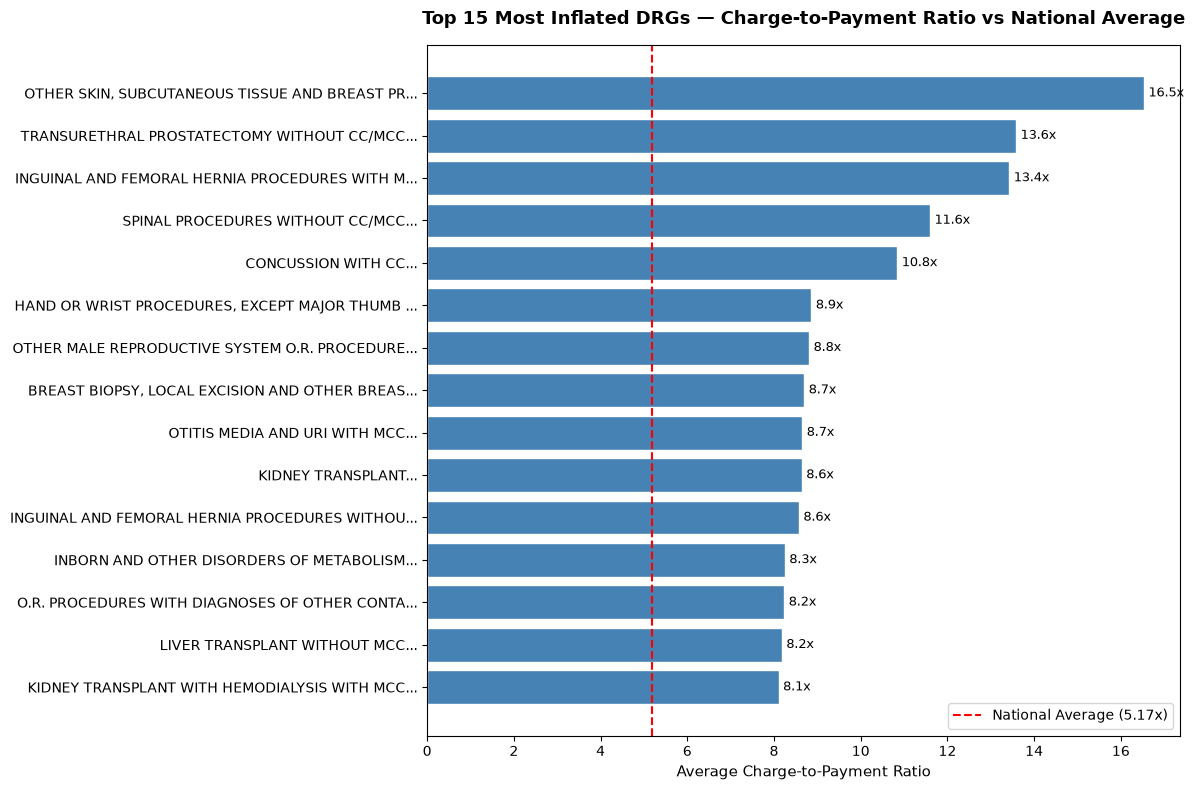

In [28]:
# ── CHART 1: Top 15 Most Inflated DRGs ────────────────────────────────────────

# Shorten DRG descriptions for readability on the chart axis
drg_inflation['short_desc'] = drg_inflation['DRG_Desc'].str[:45] + '...'

# Select top 15 by charge ratio
top15_drg = drg_inflation.head(15)

fig, ax = plt.subplots(figsize=(12, 8))

# Horizontal bar chart — easier to read long DRG descriptions
bars = ax.barh(top15_drg['short_desc'], 
               top15_drg['avg_charge_ratio'],
               color='steelblue', edgecolor='white')

# Add value labels at the end of each bar
for bar, val in zip(bars, top15_drg['avg_charge_ratio']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}x', va='center', fontsize=9)

# Add national average reference line so readers can see how far
# each DRG deviates from the norm
ax.axvline(x=standard_hospitals['charge_to_payment_ratio'].mean(),
           color='red', linestyle='--', linewidth=1.5,
           label=f'National Average (5.17x)')

ax.set_xlabel('Average Charge-to-Payment Ratio', fontsize=11)
ax.set_title('Top 15 Most Inflated DRGs — Charge-to-Payment Ratio vs National Average',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=10)
ax.invert_yaxis()  # Highest ratio at the top
plt.tight_layout()
plt.savefig('chart1_drg_inflation.png', dpi=150, bbox_inches='tight')
plt.show()

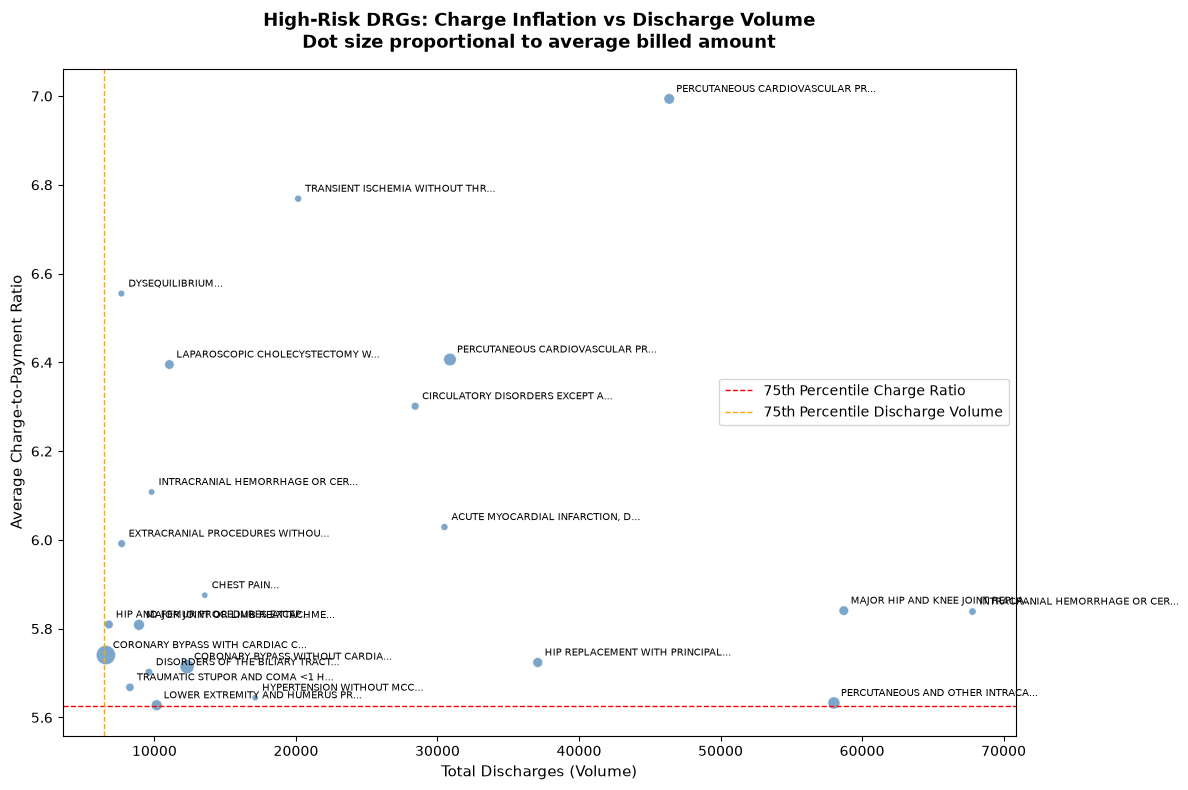

In [29]:
# ── CHART 2: High Risk DRGs — Volume vs Charge Ratio Scatter Plot ─────────────

# A scatter plot is ideal here because we are comparing TWO dimensions
# simultaneously — charge ratio (y axis) and discharge volume (x axis).
# This makes it immediately visible which DRGs are high on both metrics,
# which is the definition of high risk in this analysis.

fig, ax = plt.subplots(figsize=(12, 8))

# Plot all DRGs in the high_risk dataframe as scatter points
# Size of each dot is proportional to average billed amount —
# adding a third dimension of information without cluttering the chart
scatter = ax.scatter(
    high_risk['total_discharges'],
    high_risk['avg_charge_ratio'],
    s=high_risk['avg_billed'] / 2000,  # Scale dot size to billed amount
    alpha=0.7,
    color='steelblue',
    edgecolors='white',
    linewidth=0.5
)

# Label each dot with a shortened DRG name so the chart is self-explanatory
for _, row in high_risk.iterrows():
    ax.annotate(
        row['DRG_Desc'][:30] + '...',
        (row['total_discharges'], row['avg_charge_ratio']),
        fontsize=7,
        xytext=(5, 5),
        textcoords='offset points'
    )

# Reference lines for the 75th percentile thresholds used to define high risk
# These visually confirm the dual-threshold logic from the analysis
ax.axhline(y=drg_inflation['avg_charge_ratio'].quantile(0.75),
           color='red', linestyle='--', linewidth=1,
           label='75th Percentile Charge Ratio')
ax.axvline(x=drg_inflation['total_discharges'].quantile(0.75),
           color='orange', linestyle='--', linewidth=1,
           label='75th Percentile Discharge Volume')

ax.set_xlabel('Total Discharges (Volume)', fontsize=11)
ax.set_ylabel('Average Charge-to-Payment Ratio', fontsize=11)
ax.set_title('High-Risk DRGs: Charge Inflation vs Discharge Volume\n'
             'Dot size proportional to average billed amount',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('chart2_high_risk_drgs.png', dpi=150, bbox_inches='tight')
plt.show()

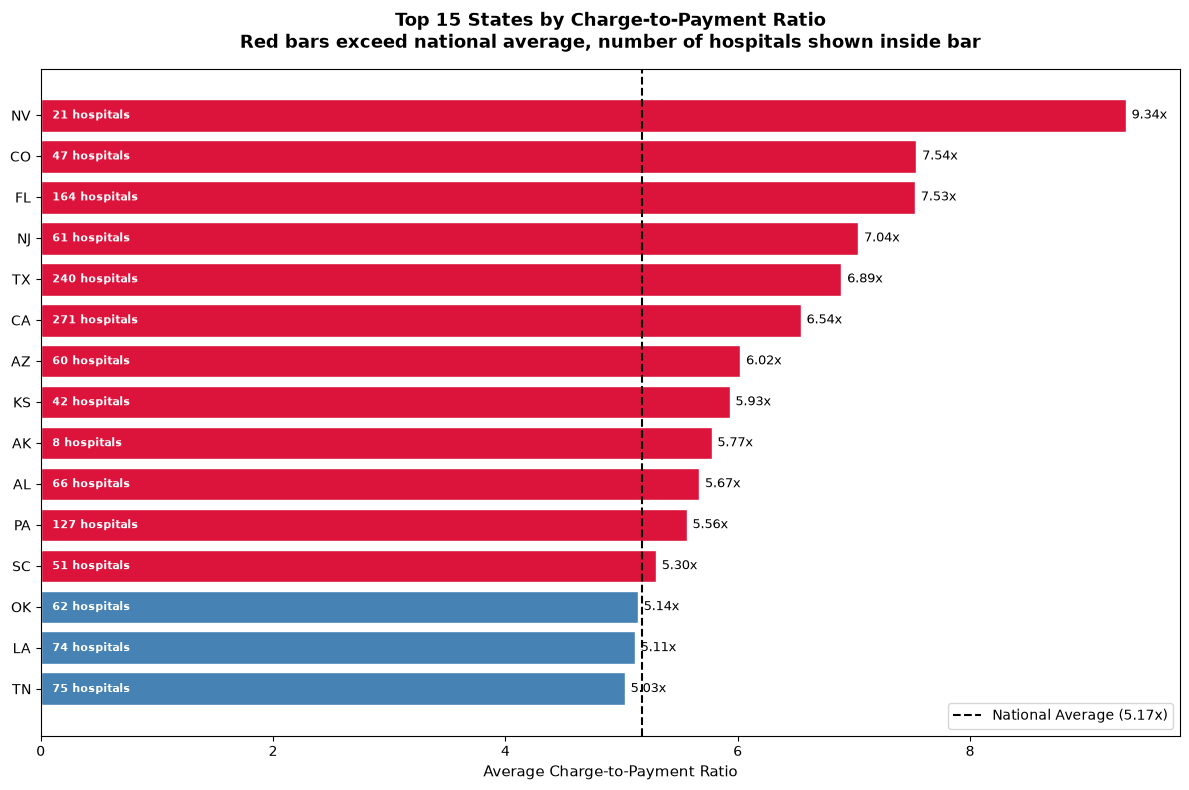

In [30]:
# ── CHART 3: Top 15 States by Charge-to-Payment Ratio ────────────────────────

# A horizontal bar chart works best here for the same reason as Chart 1 —
# state names are short enough but the values vary enough that a horizontal
# layout makes ranking immediately clear. We add a second colour layer to
# distinguish states above and below the national average, making the
# chart tell a richer story than a single-colour bar chart would.

fig, ax = plt.subplots(figsize=(12, 8))

# Select top 15 states
top15_states = state_analysis.head(15)

# Colour bars differently based on whether the state is above or below
# the national average — immediately shows which states are outliers
national_avg = standard_hospitals['charge_to_payment_ratio'].mean()
colors = ['crimson' if x > national_avg else 'steelblue' 
          for x in top15_states['avg_charge_ratio']]

bars = ax.barh(top15_states['Rndrng_Prvdr_State_Abrvtn'],
               top15_states['avg_charge_ratio'],
               color=colors, edgecolor='white')

# Add value labels at end of each bar
for bar, val in zip(bars, top15_states['avg_charge_ratio']):
    ax.text(bar.get_width() + 0.05,
            bar.get_y() + bar.get_height()/2,
            f'{val:.2f}x', va='center', fontsize=9)

# Add national average reference line
ax.axvline(x=national_avg, color='black', linestyle='--',
           linewidth=1.5, label=f'National Average ({national_avg:.2f}x)')

# Add hospital count as secondary annotation on each bar
# This distinguishes states with few outlier hospitals from those
# with systemic inflation across many facilities
for i, (_, row) in enumerate(top15_states.iterrows()):
    ax.text(0.1, i, f"{int(row['hospital_count'])} hospitals",
            va='center', fontsize=8, color='white', fontweight='bold')

ax.set_xlabel('Average Charge-to-Payment Ratio', fontsize=11)
ax.set_title('Top 15 States by Charge-to-Payment Ratio\n'
             'Red bars exceed national average, number of hospitals shown inside bar',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=10)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('chart3_state_inflation.png', dpi=150, bbox_inches='tight')
plt.show()

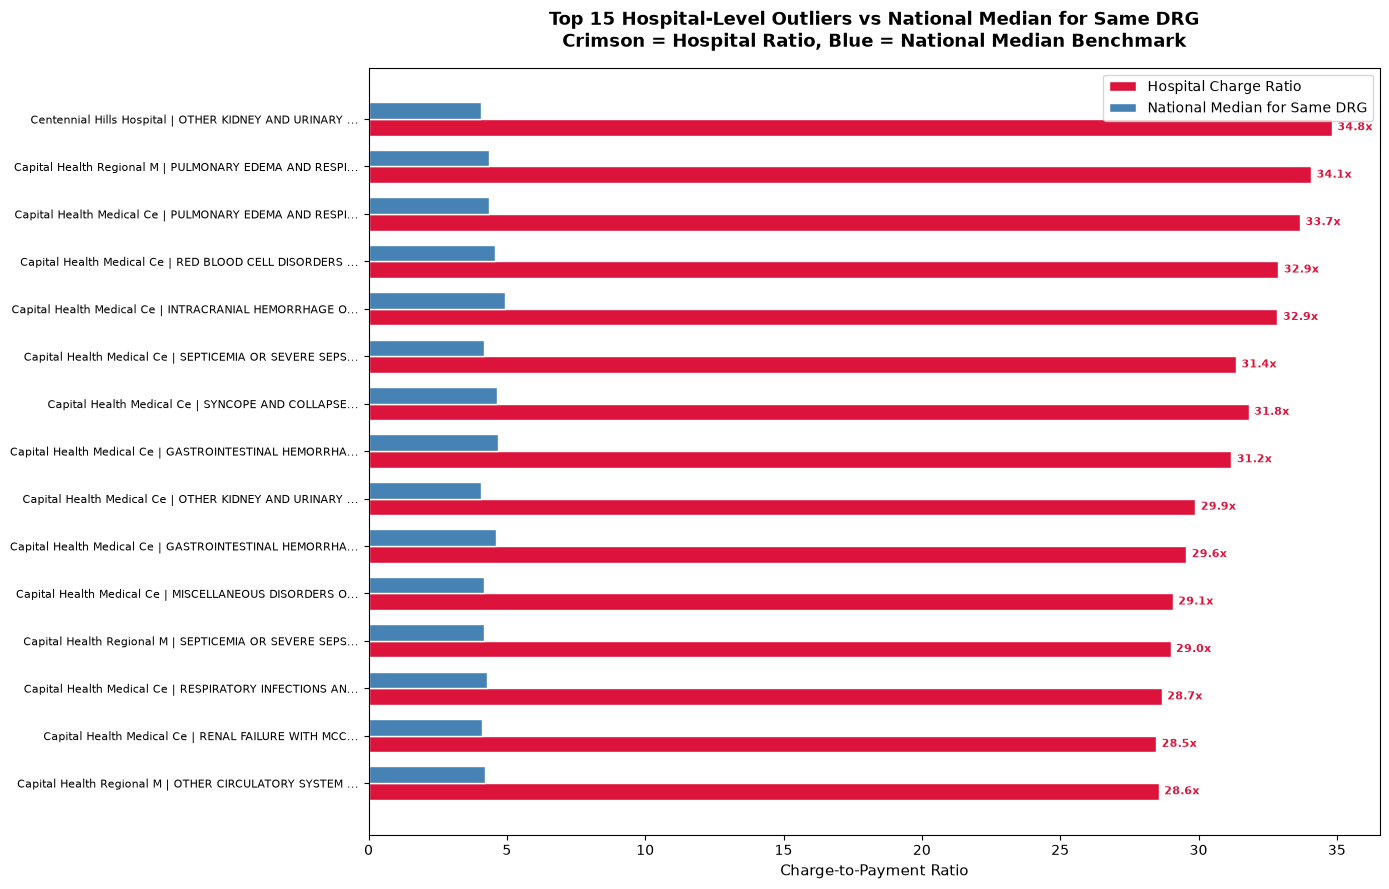

In [31]:
# ── CHART 4: Top 15 Hospital-Level Outliers ───────────────────────────────────

# This chart visualises the most extreme hospital-DRG outliers identified
# in Analysis 4. We plot both the hospital's actual ratio and the national
# median for the same DRG side by side, making the deviation immediately
# visible. This is more informative than plotting the ratio alone because
# it shows the benchmark each hospital is being compared against.

fig, ax = plt.subplots(figsize=(14, 9))

# Select top 15 outliers and create a short label combining hospital
# name and DRG description for a self-explanatory y axis
top15_outliers = top_outliers.head(15).copy()
top15_outliers['label'] = (top15_outliers['Rndrng_Prvdr_Org_Name'].str[:25] + 
                           ' | ' + 
                           top15_outliers['DRG_Desc'].str[:25] + '...')

# Set bar positions — we plot two bars per row so we need
# to offset them slightly to sit side by side
bar_height = 0.35
positions = range(len(top15_outliers))

# Hospital actual ratio — crimson to signal these are outliers
bars1 = ax.barh([p + bar_height/2 for p in positions],
                top15_outliers['charge_to_payment_ratio'],
                height=bar_height,
                color='crimson',
                label='Hospital Charge Ratio',
                edgecolor='white')

# National median for the same DRG — steelblue as the benchmark reference
bars2 = ax.barh([p - bar_height/2 for p in positions],
                top15_outliers['national_median_ratio'],
                height=bar_height,
                color='steelblue',
                label='National Median for Same DRG',
                edgecolor='white')

# Add value labels on hospital ratio bars only — the key number
# readers need to see is how far the hospital deviates from the benchmark
for bar, val in zip(bars1, top15_outliers['charge_to_payment_ratio']):
    ax.text(bar.get_width() + 0.2,
            bar.get_y() + bar.get_height()/2,
            f'{val:.1f}x', va='center', fontsize=8, color='crimson',
            fontweight='bold')

# Set y axis ticks to our label column
ax.set_yticks(list(positions))
ax.set_yticklabels(top15_outliers['label'], fontsize=8)

ax.set_xlabel('Charge-to-Payment Ratio', fontsize=11)
ax.set_title('Top 15 Hospital-Level Outliers vs National Median for Same DRG\n'
             'Crimson = Hospital Ratio, Blue = National Median Benchmark',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=10)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('chart4_hospital_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

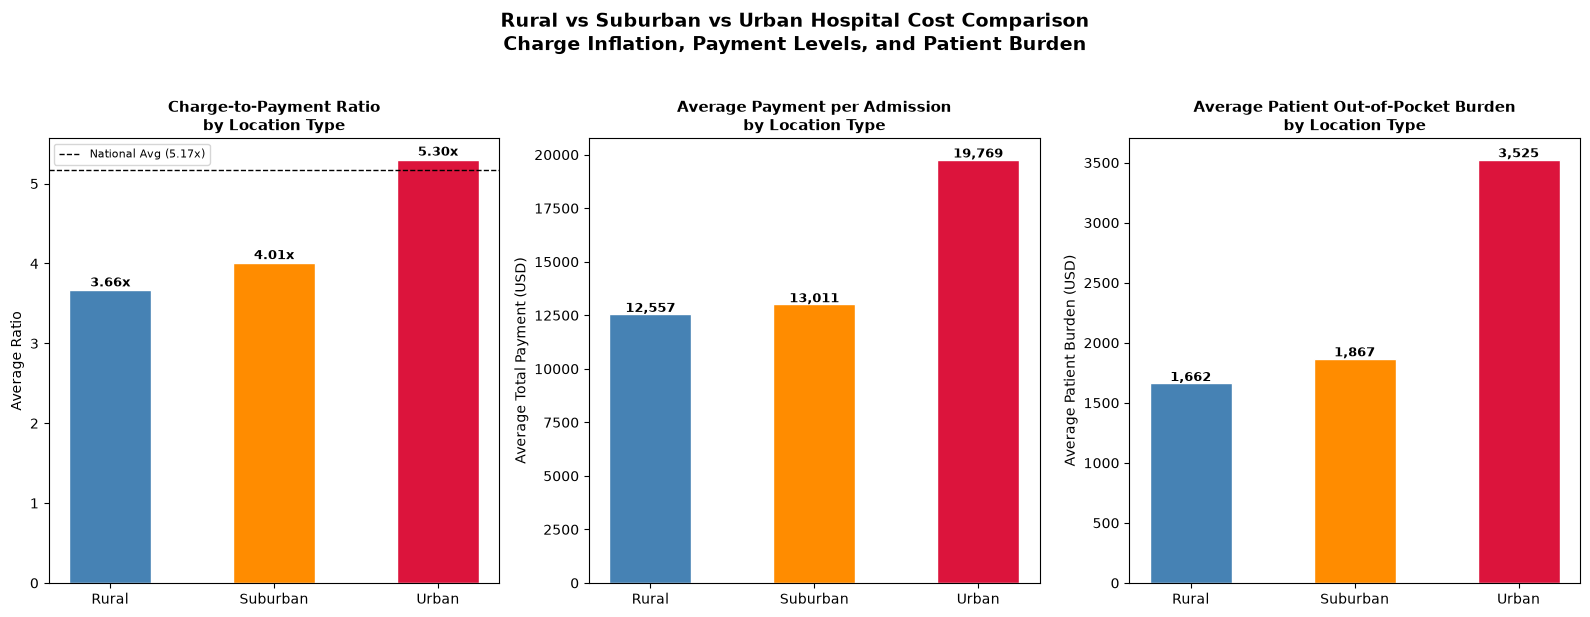

In [32]:
# ── CHART 5: Rural vs Urban Cost Comparison ───────────────────────────────────

# A grouped bar chart works best here because we are comparing multiple
# metrics across three location types simultaneously. Each metric gets
# its own group of three bars (Urban, Suburban, Rural) so the reader
# can see both the metric differences and the location differences
# in a single view.

import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# We split the comparison across three subplots to avoid overcrowding.
# Each subplot focuses on a distinct dimension of the analysis:
# cost inflation, absolute payment levels, and patient financial burden

location_types = rural_urban['location_type']
x = np.arange(len(location_types))
colors = ['steelblue', 'darkorange', 'crimson']

# ── Subplot 1: Charge-to-Payment Ratio ────────────────────────────────────────
# Shows how aggressively each location type inflates billing
axes[0].bar(x, rural_urban['avg_charge_ratio'],
            color=colors, edgecolor='white', width=0.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels(location_types, fontsize=10)
axes[0].set_title('Charge-to-Payment Ratio\nby Location Type',
                  fontsize=11, fontweight='bold')
axes[0].set_ylabel('Average Ratio', fontsize=10)

# Add value labels on top of each bar
for i, val in enumerate(rural_urban['avg_charge_ratio']):
    axes[0].text(i, val + 0.05, f'{val:.2f}x',
                 ha='center', fontsize=9, fontweight='bold')

# Add national average reference line for context
axes[0].axhline(y=national_avg, color='black',
                linestyle='--', linewidth=1,
                label=f'National Avg ({national_avg:.2f}x)')
axes[0].legend(fontsize=8)

# ── Subplot 2: Average Payment per Admission ───────────────────────────────────
# Shows absolute cost levels — rural hospitals charge and receive less
# but this does not mean care is equivalent in quality or complexity
axes[1].bar(x, rural_urban['avg_paid'],
            color=colors, edgecolor='white', width=0.5)
axes[1].set_xticks(x)
axes[1].set_xticklabels(location_types, fontsize=10)
axes[1].set_title('Average Payment per Admission\nby Location Type',
                  fontsize=11, fontweight='bold')
axes[1].set_ylabel('Average Total Payment (USD)', fontsize=10)

for i, val in enumerate(rural_urban['avg_paid']):
    axes[1].text(i, val + 100, f'{val:,.0f}',
                 ha='center', fontsize=9, fontweight='bold')

# ── Subplot 3: Average Patient Burden ─────────────────────────────────────────
# The equity dimension — how much patients pay out of pocket by location.
# Urban patients face more than double the out-of-pocket cost of rural
# patients despite having access to more facilities
axes[2].bar(x, rural_urban['avg_patient_burden'],
            color=colors, edgecolor='white', width=0.5)
axes[2].set_xticks(x)
axes[2].set_xticklabels(location_types, fontsize=10)
axes[2].set_title('Average Patient Out-of-Pocket Burden\nby Location Type',
                  fontsize=11, fontweight='bold')
axes[2].set_ylabel('Average Patient Burden (USD)', fontsize=10)

for i, val in enumerate(rural_urban['avg_patient_burden']):
    axes[2].text(i, val + 20, f'{val:,.0f}',
                 ha='center', fontsize=9, fontweight='bold')

# Overall title tying all three subplots together
fig.suptitle('Rural vs Suburban vs Urban Hospital Cost Comparison\n'
             'Charge Inflation, Payment Levels, and Patient Burden',
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('chart5_rural_urban.png', dpi=150, bbox_inches='tight')
plt.show()

In [33]:
# EXPORT CLEAN CSVS FOR TABLEAU PUBLIC 

# We export one CSV per analysis, each containing exactly the columns
# Tableau needs to build the dashboard. Keeping them separate makes
# it easier to connect each sheet in Tableau to the right data source
# without filtering or confusion.

import os

# Create a dedicated folder to keep exports organised
output_folder = 'tableau_exports'
os.makedirs(output_folder, exist_ok=True)

# Export 1: DRG Inflation (Analysis 1) 
# Used for: Top 15 inflated DRGs bar chart in Tableau
drg_inflation.to_csv(f'{output_folder}/drg_inflation.csv', index=False)
print("Exported: drg_inflation.csv")

# Export 2: High Risk DRGs (Analysis 2)
# Used for: Volume vs inflation scatter plot in Tableau
high_risk.to_csv(f'{output_folder}/high_risk_drgs.csv', index=False)
print("Exported: high_risk_drgs.csv")

# Export 3: State Level Analysis (Analysis 3) 
# Used for: State heatmap and bar chart in Tableau
# Tableau recognises US state abbreviations natively for map visualisations
state_analysis.to_csv(f'{output_folder}/state_analysis.csv', index=False)
print("Exported: state_analysis.csv")

# Export 4: Hospital Outliers (Analysis 4) 
# Used for: Hospital outlier comparison chart in Tableau
# We export the full outliers dataframe, not just top 15,
# so Tableau can filter interactively by state or DRG
outliers[['Rndrng_Prvdr_Org_Name', 'Rndrng_Prvdr_State_Abrvtn',
          'Rndrng_Prvdr_City', 'DRG_Desc',
          'charge_to_payment_ratio', 'national_median_ratio',
          'ratio_vs_median', 'Avg_Submtd_Cvrd_Chrg',
          'Avg_Tot_Pymt_Amt', 'Tot_Dschrgs']].to_csv(
    f'{output_folder}/hospital_outliers.csv', index=False)
print("Exported: hospital_outliers.csv")

#  Export 5: Rural vs Urban Analysis (Analysis 5) 
# Used for: Location type comparison charts in Tableau
rural_urban.to_csv(f'{output_folder}/rural_urban_analysis.csv', index=False)
print("Exported: rural_urban_analysis.csv")

# Export 6: Special Payment Hospitals (Segmentation Finding) 
# Used for: Reference table in Tableau showing excluded hospitals
# and why — adds transparency to the analysis
special_payment_hospitals[['Rndrng_Prvdr_Org_Name', 'Rndrng_Prvdr_State_Abrvtn',
                            'Rndrng_Prvdr_City', 'DRG_Desc',
                            'Avg_Submtd_Cvrd_Chrg', 'Avg_Tot_Pymt_Amt',
                            'cost_gap']].to_csv(
    f'{output_folder}/special_payment_hospitals.csv', index=False)
print("Exported: special_payment_hospitals.csv")

print(f"\nAll exports complete. Files saved to: {output_folder}/")
print(f"Total files exported: 6")

Exported: drg_inflation.csv
Exported: high_risk_drgs.csv
Exported: state_analysis.csv
Exported: hospital_outliers.csv
Exported: rural_urban_analysis.csv
Exported: special_payment_hospitals.csv

All exports complete. Files saved to: tableau_exports/
Total files exported: 6
